In [33]:
import pandas as pd
from openbb import obb
obb.user.preferences.output_type = "dataframe"

In [34]:
data = obb.derivatives.futures.curve(symbol="GC")

In [35]:
print(data)

   expiration    price
0     2024-12  2691.80
1     2025-01  2684.45
2     2025-02  2714.80
3     2025-04  2727.00
4     2025-06  2769.80
5     2025-08  2789.50
6     2025-10  2798.20
7     2025-12  2809.00
8     2026-02  2838.25
9     2026-04  2856.60
10    2026-06  2892.60
11    2026-12  6450.00


<Axes: xlabel='expiration'>

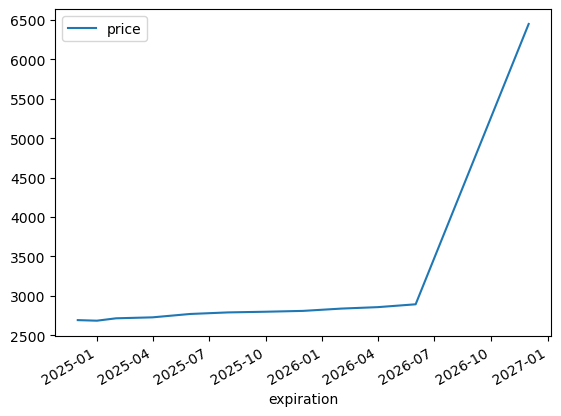

In [36]:
data.index = pd.to_datetime(data.expiration)
data.plot()

In [37]:
expirations = [
    "2024-12",
    "2025-12",
    "2026-12",
    "2027-12",
    "2028-12",
    "2029-12",
    "2030-12",
]

In [38]:
contracts = []
for expiration in expirations:
    df = (
        obb
        .derivatives
        .futures
        .historical(
            symbol="CL",
            expiration=expiration,
            start_date="2020-01-01",
            end_date="2022-12-31",
        )
    ).rename(columns={
        "close": expiration
    })
    contracts.append(df[expiration])

In [39]:
historical = (
    pd
    .DataFrame(contracts)
    .transpose()
    .dropna()
)

In [40]:
print(historical)

              2024-12    2025-12    2026-12    2027-12    2028-12    2029-12  \
date                                                                           
2020-01-02  52.099998  52.750000  53.130001  53.180000  53.180000  53.180000   
2020-01-03  51.669998  52.419998  52.910000  52.959999  52.959999  52.959999   
2020-01-06  51.630001  52.349998  52.840000  52.889999  52.889999  52.889999   
2020-01-07  51.939999  52.669998  53.169998  53.240002  53.240002  53.240002   
2020-01-08  51.540001  52.270000  52.770000  52.840000  52.840000  52.840000   
...               ...        ...        ...        ...        ...        ...   
2022-12-23  71.570000  67.779999  64.669998  62.119999  59.990002  58.139999   
2022-12-27  71.680000  67.860001  64.730003  62.180000  60.049999  58.200001   
2022-12-28  71.820000  68.290001  65.339996  62.790001  60.650002  58.790001   
2022-12-29  70.980003  67.500000  64.599998  62.119999  59.980000  58.119999   
2022-12-30  72.309998  68.629997  65.620

<Axes: >

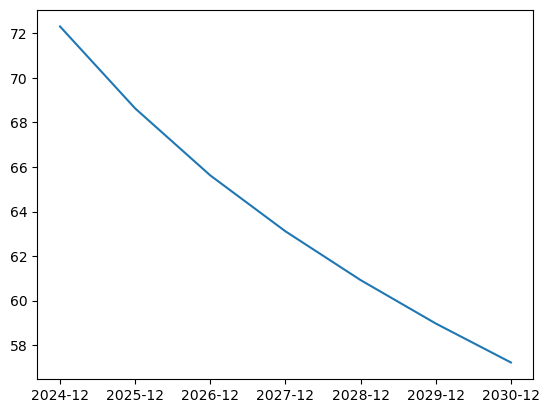

In [41]:
historical.iloc[-1].plot()